# Setup

In [2]:
import random
import numpy as np
from PIL import Image, ImageDraw, ImageFilter, ImageOps
from pathlib import Path
import matplotlib.pyplot as plt

BASE = Path(r"C:\Users\npd20\Downloads\ĐACN_v2")
KAGGLE = BASE / "data" / "raw" / "kaggle_digits"
OUT = BASE / "data" / "processed" / "synthetic_cells"
OUT.mkdir(parents=True, exist_ok=True)

# Score space
SCORES = (
    [f"{i}.{d}" for i in range(0, 10) for d in [0, 3, 5, 8]]
    + ["10"]
)
print(f"Total score classes: {len(SCORES)}")
print(SCORES)

Total score classes: 41
['0.0', '0.3', '0.5', '0.8', '1.0', '1.3', '1.5', '1.8', '2.0', '2.3', '2.5', '2.8', '3.0', '3.3', '3.5', '3.8', '4.0', '4.3', '4.5', '4.8', '5.0', '5.3', '5.5', '5.8', '6.0', '6.3', '6.5', '6.8', '7.0', '7.3', '7.5', '7.8', '8.0', '8.3', '8.5', '8.8', '9.0', '9.3', '9.5', '9.8', '10']


# Load digits từ Kaggle

In [3]:
# Load tất cả ảnh theo class vào dict
digit_pool = {}

for class_dir in sorted(KAGGLE.iterdir()):
    if not class_dir.is_dir():
        continue
    imgs = list(class_dir.glob("*.png")) + list(class_dir.glob("*.jpg"))
    digit_pool[class_dir.name] = imgs

print("Digit pool:")
for k, v in sorted(digit_pool.items()):
    print(f"  Digit {k}: {len(v)} images")

Digit pool:
  Digit 0: 2236 images
  Digit 1: 2241 images
  Digit 2: 2233 images
  Digit 3: 2202 images
  Digit 4: 2179 images
  Digit 5: 2126 images
  Digit 6: 2121 images
  Digit 7: 2116 images
  Digit 8: 2085 images
  Digit 9: 2016 images


# Hàm lấy digit ngẫu nhiên

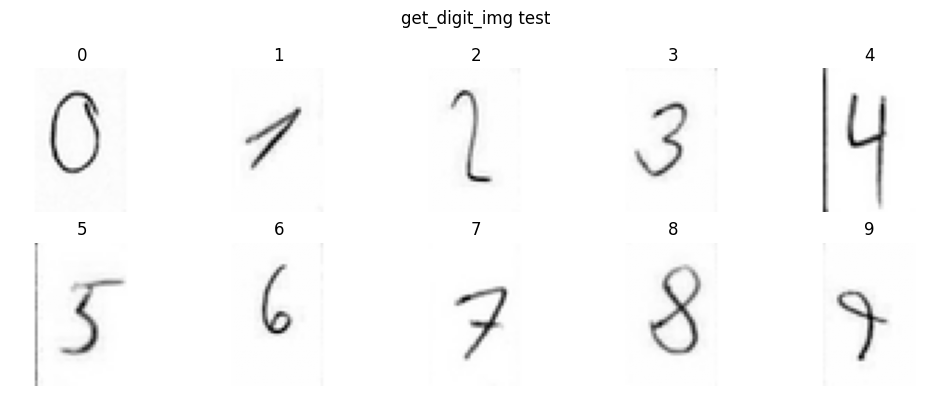

In [4]:
def get_digit_img(digit: str, size: int = 52) -> Image.Image:
    """Lấy 1 ảnh digit ngẫu nhiên, resize về hình vuông size×size, nền trắng chữ đen."""
    path = random.choice(digit_pool[digit])
    img = Image.open(path).convert("L")
    
    # Đảm bảo chữ đen nền trắng
    arr = np.array(img)
    if arr.mean() < 128:  # nền đen → invert
        img = ImageOps.invert(img)
    
    # Resize giữ tỉ lệ, pad về size×size
    img.thumbnail((size, size), Image.LANCZOS)
    canvas = Image.new("L", (size, size), 255)
    x = (size - img.width) // 2
    y = (size - img.height) // 2
    canvas.paste(img, (x, y))
    return canvas

# Test
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, d in enumerate("0123456789"):
    axes.flatten()[i].imshow(get_digit_img(d), cmap="gray")
    axes.flatten()[i].set_title(d)
    axes.flatten()[i].axis("off")
plt.suptitle("get_digit_img test")
plt.tight_layout()
plt.show()

#  Hàm vẽ dấu phẩy giả lập

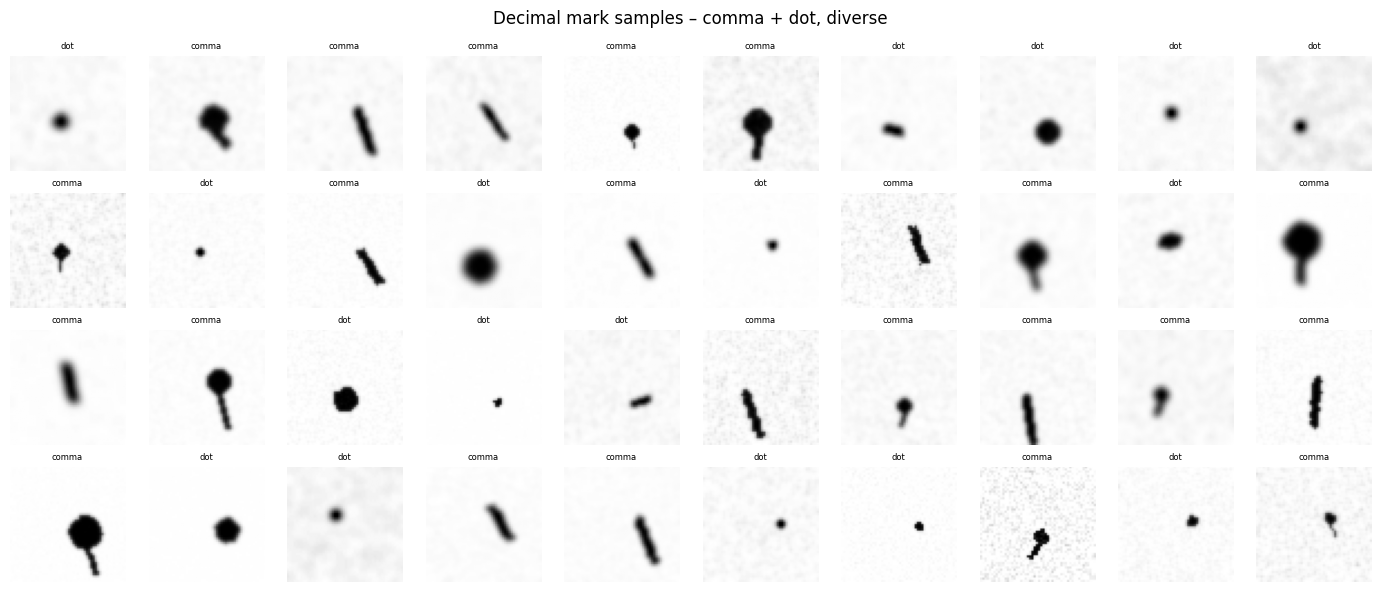

In [7]:
def get_decimal_mark_img(size: int = 52) -> Image.Image:
    canvas = Image.new("L", (size, size), 255)
    draw = ImageDraw.Draw(canvas)
    
    cx = size // 2 + random.randint(-8, 8)
    cy = size // 2 + random.randint(-6, 8)
    
    mark_type = random.choice(["comma", "dot"])
    style = random.randint(0, 4)
    
    if mark_type == "dot":
        # Chấm: tròn / oval / nét ngang / nét dọc ngắn / to / nhỏ
        if style == 0:
            r = random.randint(2, 5)
            draw.ellipse([cx-r, cy-r, cx+r, cy+r], fill=0)
        elif style == 1:
            # Oval ngang
            draw.ellipse([cx-5, cy-3, cx+5, cy+3], fill=0)
        elif style == 2:
            # Gạch ngang ngắn
            draw.line([cx-4, cy, cx+4, cy], fill=0, width=random.randint(2,4))
        elif style == 3:
            # Chấm rất nhỏ
            draw.ellipse([cx-1, cy-1, cx+2, cy+2], fill=0)
        elif style == 4:
            # Chấm to nhòe
            r = random.randint(6, 9)
            draw.ellipse([cx-r, cy-r, cx+r, cy+r], fill=random.randint(0, 80))

    else:  # comma
        if style == 0:
            # Tròn + đuôi thẳng
            r = random.randint(3, 6)
            draw.ellipse([cx-r, cy-r, cx+r, cy+r], fill=0)
            draw.line([cx, cy+r, cx+random.randint(-3,3), cy+r+random.randint(6,12)],
                      fill=0, width=random.randint(2,4))
        elif style == 1:
            # Gạch chéo
            draw.line([cx-2, cy-6, cx+5, cy+10], fill=0, width=random.randint(2,4))
        elif style == 2:
            # Phẩy cong
            for t in np.linspace(0, 1, 12):
                px = int(cx + 3*t)
                py = int(cy - 4 + 14*t + 5*t*t)
                draw.ellipse([px-1, py-1, px+2, py+2], fill=0)
        elif style == 3:
            # Phẩy nhỏ xíu
            r = random.randint(1, 3)
            draw.ellipse([cx-r, cy-r, cx+r, cy+r], fill=0)
            draw.line([cx, cy+r, cx+1, cy+r+random.randint(3,6)], fill=0, width=1)
        elif style == 4:
            # Phẩy lớn đậm
            r = random.randint(5, 8)
            draw.ellipse([cx-r, cy-r, cx+r, cy+r], fill=0)
            draw.line([cx, cy+r, cx+random.randint(-4,4), cy+r+random.randint(10,18)],
                      fill=0, width=random.randint(3,5))

    # Random rotation nhẹ
    angle = random.uniform(-15, 15)
    canvas = canvas.rotate(angle, fillcolor=255)

    # Noise
    arr = np.array(canvas).astype(np.float32)
    arr += np.random.normal(0, random.uniform(0, 20), arr.shape)
    arr = np.clip(arr, 0, 255).astype(np.uint8)
    canvas = Image.fromarray(arr)

    # Blur
    canvas = canvas.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.3, 2.0)))

    return canvas, mark_type

# Test
fig, axes = plt.subplots(4, 10, figsize=(14, 6))
for ax in axes.flatten():
    img, mtype = get_decimal_mark_img()
    ax.imshow(img, cmap="gray")
    ax.set_title(mtype, fontsize=6)
    ax.axis("off")
plt.suptitle("Decimal mark samples – comma + dot, diverse")
plt.tight_layout()
plt.show()

#  Hàm tạo 1 synthetic cell

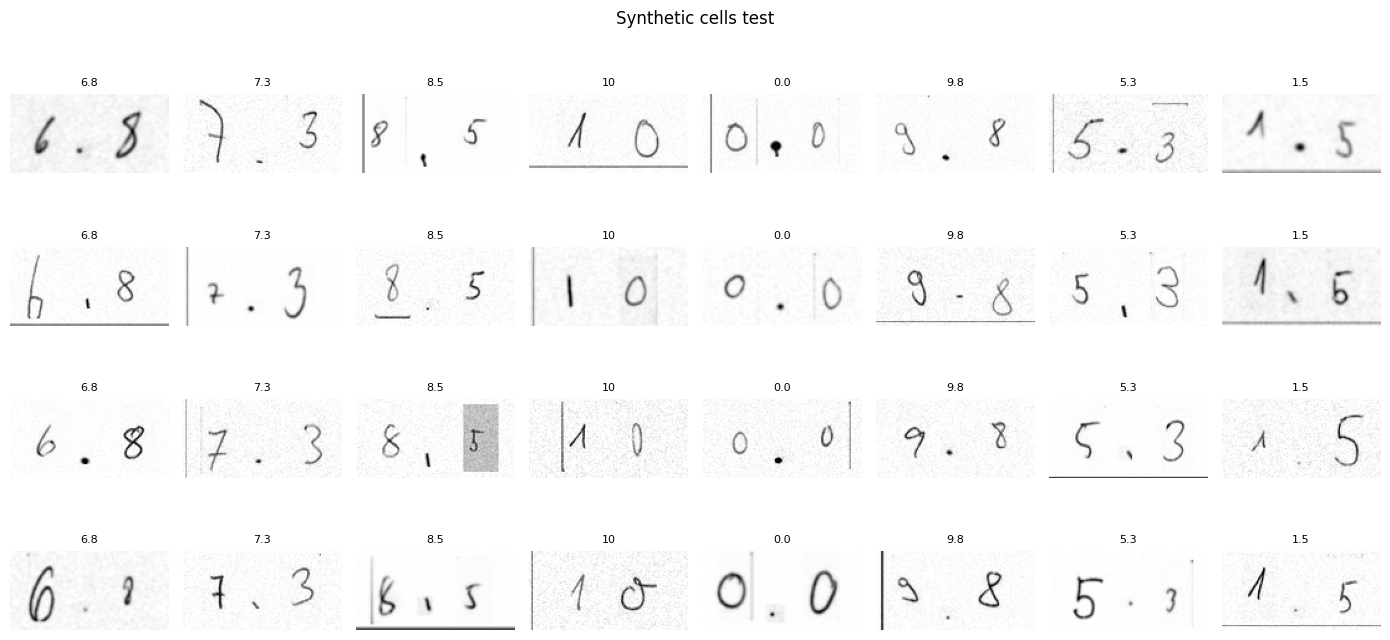

In [10]:
def make_synthetic_cell(score: str, mark_type: str = None, 
                         out_w: int = 128, out_h: int = 64) -> Image.Image:
    """
    Tạo 1 ảnh cell hoàn chỉnh từ score string.
    score: '6.8', '7.3', '10', ...
    mark_type: 'comma', 'dot', hoặc None (random)
    """
    if mark_type is None:
        mark_type = random.choice(["comma", "dot"])

    canvas = Image.new("L", (out_w, out_h), 255)

    if score == "10":
        # Đặc biệt: 2 chữ số, không có dấu
        d1 = get_digit_img("1", size=52)
        d2 = get_digit_img("0", size=52)
        # Scale xuống vừa canvas
        d1 = d1.resize((48, 56))
        d2 = d2.resize((48, 56))
        x1 = (out_w // 2) - 50 + random.randint(-4, 4)
        x2 = (out_w // 2) + 2 + random.randint(-4, 4)
        y = (out_h - 56) // 2 + random.randint(-3, 3)
        canvas.paste(d1, (x1, y))
        canvas.paste(d2, (x2, y))
    else:
        left_digit, right_digit = score.split(".")
        
        d_left  = get_digit_img(left_digit, size=48)
        mark, _ = get_decimal_mark_img(size=28)
        d_right = get_digit_img(right_digit, size=48)

        d_left  = d_left.resize((44, 54))
        mark    = mark.resize((random.randint(10, 16), random.randint(10, 16)))  # nhỏ hơn nhiều
        d_right = d_right.resize((44, 54))

        # Vị trí
        x_left  = random.randint(4, 10)
        x_mark  = x_left + 44 + random.randint(0, 4)
        x_right = x_mark + 22 + random.randint(0, 4)
        y_digit = (out_h - 54) // 2 + random.randint(-3, 3)
        y_mark = (out_h - 54) // 2 + random.randint(30, 42)  # thấp hơn

        canvas.paste(d_left,  (x_left, y_digit))
        canvas.paste(mark,    (x_mark, y_mark))
        canvas.paste(d_right, (x_right, y_digit))

    # Augmentation
    # 1. Thêm đường kẻ bảng (50% chance)
    if random.random() < 0.5:
        draw = ImageDraw.Draw(canvas)
        if random.random() < 0.5:
            y_line = random.randint(out_h-6, out_h-1)
            draw.line([0, y_line, out_w, y_line], fill=random.randint(80,180), 
                      width=random.randint(1,2))
        else:
            x_line = random.randint(0, 6)
            draw.line([x_line, 0, x_line, out_h], fill=random.randint(80,180),
                      width=random.randint(1,2))

    # 2. Noise
    arr = np.array(canvas).astype(np.float32)
    arr += np.random.normal(0, random.uniform(0, 15), arr.shape)
    arr = np.clip(arr, 0, 255).astype(np.uint8)
    canvas = Image.fromarray(arr)

    # 3. Blur nhẹ
    if random.random() < 0.4:
        canvas = canvas.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.3, 1.2)))

    # 4. Contrast ngẫu nhiên
    from PIL import ImageEnhance
    factor = random.uniform(0.7, 1.3)
    canvas = ImageEnhance.Contrast(canvas).enhance(factor)

    return canvas

# Test
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
test_scores = ["6.8", "7.3", "8.5", "10", "0.0", "9.8", "5.3", "1.5"] * 4
for ax, sc in zip(axes.flatten(), test_scores):
    img = make_synthetic_cell(sc)
    ax.imshow(img, cmap="gray")
    ax.set_title(sc, fontsize=8)
    ax.axis("off")
plt.suptitle("Synthetic cells test")
plt.tight_layout()
plt.show()

#  generate.

In [11]:
from tqdm import tqdm

N_PER_CLASS = 5000  # 2500 comma + 2500 dot

for score in SCORES:
    score_dir = OUT / score.replace(".", "_")
    score_dir.mkdir(parents=True, exist_ok=True)

for score in tqdm(SCORES, desc="Generating"):
    score_dir = OUT / score.replace(".", "_")
    
    for i in range(N_PER_CLASS // 2):
        img = make_synthetic_cell(score, mark_type="comma")
        img.save(score_dir / f"comma_{i:04d}.png")
        
        img = make_synthetic_cell(score, mark_type="dot")
        img.save(score_dir / f"dot_{i:04d}.png")

print(f"Done! Total: {N_PER_CLASS * len(SCORES):,} images")

Generating: 100%|██████████| 41/41 [08:36<00:00, 12.59s/it]

Done! Total: 205,000 images


In [12]:
# Kiểm tra số lượng thực tế
total = 0
for score_dir in sorted(OUT.iterdir()):
    if score_dir.is_dir():
        count = len(list(score_dir.glob("*.png")))
        total += count
        if count != 5000:
            print(f"WARNING: {score_dir.name}: {count} images")

print(f"Total: {total:,} images across {len(list(OUT.iterdir()))} classes")
print("All good!" if total == 205000 else "SOMETHING WRONG!")

Total: 205,000 images across 41 classes
All good!
